In [6]:
from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.215")

192.168.1.215:50051


_InactiveRpcError: <_InactiveRpcError of RPC that terminated with:
	status = StatusCode.UNAVAILABLE
	details = "failed to connect to all addresses; last error: UNAVAILABLE: ipv4:192.168.1.215:50051: ConnectEx: Connection timed out (A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond.
 -- 10060)"
	debug_error_string = "UNKNOWN:Error received from peer  {grpc_message:"failed to connect to all addresses; last error: UNAVAILABLE: ipv4:192.168.1.215:50051: ConnectEx: Connection timed out (A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond.\r\n -- 10060)", grpc_status:14, created_time:"2026-02-20T11:00:31.9034929+00:00"}"
>

In [4]:
from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.120")
got.open_camera()

from IPython.display import clear_output, Image
import numpy as np
import cv2

192.168.1.120:50051


In [ ]:
while True:
    frame = got.read_camera_data()
    nparr = np.frombuffer(frame, np.uint8)
    data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    cv2.imshow("UGOT camera", data)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()

No camera data received


TypeError: a bytes-like object is required, not 'NoneType'

In [12]:
def line_follow(mult=0.25, speed=20):
    offset, type, x, y = got.get_single_track_total_info()
    rotation_speed = int(offset * mult)
    print(offset, end = "             \r")

    got.mecanum_move_xyz(x_speed=0, y_speed=speed, z_speed=rotation_speed)

    return type, x, y

while True:
    type, x, y = line_follow(mult = 0.4, speed = 30)


KeyboardInterrupt: 

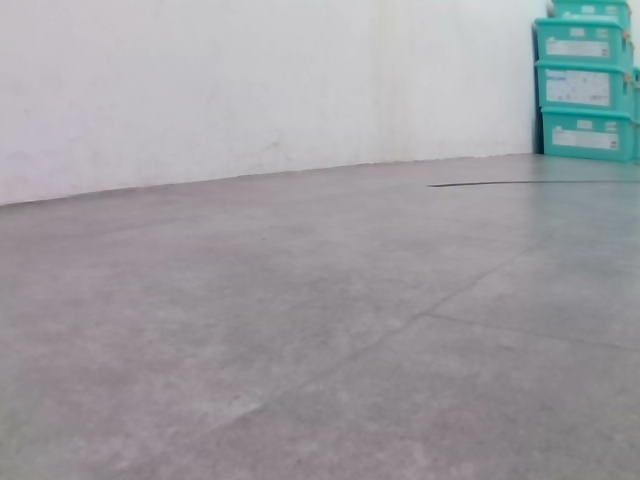

KeyboardInterrupt: 

In [ ]:
def text_rec():
    text = got.get_words_result()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if text:
            cv2.putText(data, text, (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return text
    
while True:
    text = text_rec()
    print(text, end="       \r")

In [ ]:
def color_rec():
    color_info = got.get_color_total_info()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if color_info[0]:
            cv2.putText(data, color_info[0], (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            c_x = color_info[2]
            c_y = color_info[3]
            h = color_info[4]
            w = color_info[5]

            cv2.rectangle(data, (int(c_x - w / 2), int(c_y - h / 2)), 
                            (int(c_x + w / 2), int(c_y + h / 2)), (0, 0, 255), 2)
            

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return color_info[0]
    
while True:
    color = color_rec()
    print(color, end = "      \r")

AttributeError: module 'numpy' has no attribute 'unit8'